# XGBoost - Model Development Workflow

> **MLCourse · Machine Learning · supervised · classification**

Production pattern on REAL breast-cancer data (`data/breast_cancer.csv`):
train/validation split for EARLY STOPPING, then a compact grid, then feature
importance audit.

## What you'll learn
- `early_stopping_rounds` + `eval_set` = automatic round selection
- Tuning depth/lr/subsample the XGB way
- Reading gain-based importances

best iteration : 125
test acc       : 0.9600


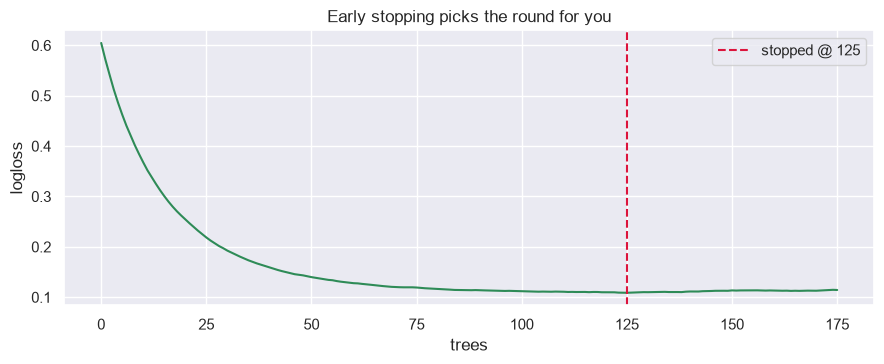

,pred malignant,pred benign
true malignant,112,3
true benign,4,56


In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

bc = pd.read_csv(ML_ROOT / "data" / "breast_cancer.csv")
bc.columns = [c.strip().lower().replace(" ", "_") for c in bc.columns]
bc["target"] = (bc["class"] == "malignant").astype(int)
bc = bc.drop(columns="class")
for c in bc.columns[bc.isna().any()]:
    bc[c] = bc[c].fillna(bc[c].median())

y = bc.pop("target").values
X_tr, X_te, y_tr, y_te = train_test_split(bc.values.astype(float), y,
                                          test_size=.25, random_state=42,
                                          stratify=y)

model = XGBClassifier(n_estimators=800, learning_rate=0.05, max_depth=3,
                      subsample=0.8, colsample_bytree=0.8,
                      early_stopping_rounds=50,
                      eval_metric="logloss", random_state=42)
model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

print(f"best iteration : {model.best_iteration}")
print(f"test acc       : {accuracy_score(y_te, model.predict(X_te)):.4f}")

res = model.evals_result()
plt.figure(figsize=(9, 3.8))
plt.plot(res["validation_0"]["logloss"], color="seagreen")
plt.axvline(model.best_iteration, ls="--", c="crimson",
            label=f"stopped @ {model.best_iteration}")
plt.xlabel("trees"); plt.ylabel("logloss"); plt.legend()
plt.title("Early stopping picks the round for you")
plt.tight_layout(); plt.show()

pd.DataFrame(confusion_matrix(y_te, model.predict(X_te)),
             index=["true malignant", "true benign"],
             columns=["pred malignant", "pred benign"])

## Feature audit - gain vs weight

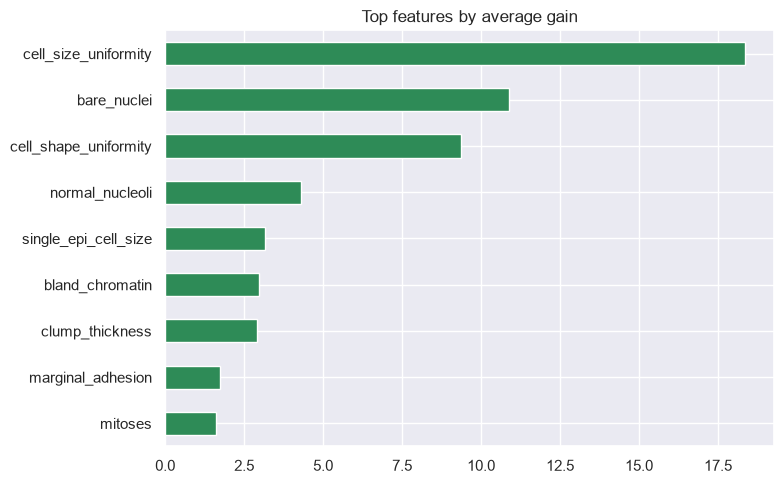

In [2]:
booster_gain = model.get_booster().get_score(importance_type="gain")
imp = (pd.Series(booster_gain).sort_values()).tail(10)
names = {f"f{i}": col for i, col in enumerate(bc.columns)}
imp.index = imp.index.map(lambda k: names.get(k, k))

plt.figure(figsize=(8, 5))
imp.plot(kind="barh", color="seagreen")
plt.title("Top features by average gain")
plt.tight_layout(); plt.show()

## Summary & key takeaways

- Early stopping converts "how many trees?" into an observed measurement.
- Gain importances highlight features that IMPROVE the objective, not just
  frequency of use.
- Same tabular recipe as GBM with stronger guardrails (λ, γ, NaN routing).